# ATN DAC Quality Control Example

This notebook demonstrates how to apply quality control (QC) tests to Animal Telemetry Network (ATN) satellite telemetry data using the [`ioos_qc`](https://github.com/ioos/ioos_qc) Python package (see [docs](https://ioos.github.io/ioos_qc/)).

The ATN DAC applies automated QC to all auto-ingested trajectory and profile data from Wildlife Computers and SMRU instruments. This notebook shows the exact tests and thresholds used in our operational pipeline, allowing users to:

1. Understand what QC is being applied to ATN data
2. Replicate the QC process on their own data
3. Interpret the QC flags embedded in ATN data products

### QC Tests Applied

#### Trajectory QC
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `location_test` | `ioos_qc.qartod` | bbox: [-180, -90, 180, 90] | Valid geographic bounds |
| `speed_test` | `ioos_qc.argo` | suspect: 8 m/s, fail: 10 m/s | Realistic movement speeds |
| `valid_range_test` | `ioos_qc.axds` | deployment dates | Deployment period bounds |

#### Profile/Time-Series QC
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `gross_range_test` | `ioos_qc.qartod` | temp: [-2.5, 40]°C | Physical sensor bounds |
| `gross_range_test` | `ioos_qc.qartod` | salinity: [0, 41] PSU | Physical sensor bounds |
| `valid_range_test` | `ioos_qc.axds` | deployment dates | Deployment period bounds |

Please see the [ATN Satellite Telemetry Specifications, Quality Control Protocols section](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html#quality-control-protocols) for more details on QC flag values, tests applied, and configured thresholds.

## Import Required Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np
import io
import zipfile
import requests

# QC libraries
from ioos_qc.config import Config
from ioos_qc.streams import PandasStream
from ioos_qc.stores import PandasStore
from ioos_qc.utils import great_circle_distance

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Fetch ATN Data

We'll use **real deployment data** from the ATN Data Assembly Center. This example uses Wildlife Computers satellite tag data.

The data is accessed directly from the ATN data portal at [portal.atn.ioos.us](https://portal.atn.ioos.us).

### Wildlife Computers Data Format

Wildlife Computers tags produce several data types:
- **Argos** - Satellite-derived positions with location class quality indicators
- **FastGPS** - Higher-accuracy GPS positions (when available)
- **Series** - Time-series data (temperature, depth)
- **Histos** - Histogram summaries of behavior

For trajectory QC, we primarily use the **Locations** data which includes:
- Date/time of each position fix
- Latitude and Longitude
- Location Class (quality indicator: 3, 2, 1, 0, A, B, Z)
- Error ellipse parameters

Let's get real ATN deployment data from the ATN portal. 

Here is a project page on the ATN portal: https://portal.atn.ioos.us/#metadata/5333b110-dbd1-4e66-ab69-f064e20a7034/project

We'll use the data from a Mahi mahi with a tag id of `254053` from here: https://workspace.aoos.org/published/file/1989e709-af65-4250-9413-637d5cea36f4/254053O2024.zip?source=catalog&portalId=99

In [2]:
# Download real ATN deployment data from Wildlife Computers

deployment_url = "https://workspace.aoos.org/published/file/1989e709-af65-4250-9413-637d5cea36f4/254053O2024.zip?source=catalog&portalId=99"

response = requests.get(deployment_url)
response.raise_for_status()

# Extract the ZIP file contents
zip_buffer = io.BytesIO(response.content)
zf = zipfile.ZipFile(zip_buffer)

# List files in the ZIP
print(f"\nFiles in deployment ZIP:")
for filename in sorted(zf.namelist()):
    print(f"  - {filename}")


Files in deployment ZIP:
  - 254053O2024/
  - 254053O2024/254053-10-GPE3.csv
  - 254053O2024/254053-10-GPE3.kmz
  - 254053O2024/254053-10-GPE3.nc
  - 254053O2024/254053-All.csv
  - 254053O2024/254053-Argos.csv
  - 254053O2024/254053-Corrupt.csv
  - 254053O2024/254053-Histos.csv
  - 254053O2024/254053-Labels.csv
  - 254053O2024/254053-LightLoc.csv
  - 254053O2024/254053-Locations.csv
  - 254053O2024/254053-MinMaxDepth.csv
  - 254053O2024/254053-MixLayer.csv
  - 254053O2024/254053-PDTs.csv
  - 254053O2024/254053-RTC.csv
  - 254053O2024/254053-RawArgos.csv
  - 254053O2024/254053-SST.csv
  - 254053O2024/254053-Series.csv
  - 254053O2024/254053-SeriesRange.csv
  - 254053O2024/254053-Status.csv
  - 254053O2024/254053-Summary.csv
  - 254053O2024/254053.kmz
  - 254053O2024/254053.prv
  - 254053O2024/254053.pxp
  - 254053O2024/setup.rtf
  - 254053O2024/sources.txt


## QC Trajectory Data

### 0. Prepare Data

In [3]:
# Load the Argos position data in the Locations file for trajectory QC

argos_file = "254053O2024/254053-Locations.csv"

with zf.open(argos_file) as f:
    trajectory_df = pd.read_csv(f)

In [4]:
# Show first few records
print("\nFirst 5 records:")
trajectory_df.head()


First 5 records:


,DeployID,Ptt,Instr,Date,Type,Quality,Latitude,Longitude,Error radius,Error Semi-major axis,Error Semi-minor axis,Error Ellipse orientation,Offset,Offset orientation,GPE MSD,GPE U,Count,Comment
0,254053,254053,MiniPAT,02:03:56 31-Mar-2024,Argos,0,11.8863,-100.2372,4738,13416.0,1673.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN
1,254053,254053,MiniPAT,02:30:43 31-Mar-2024,Argos,2,11.9007,-100.2494,347,454.0,264.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN
2,254053,254053,MiniPAT,03:03:54 31-Mar-2024,Argos,1,11.9024,-100.2447,901,2404.0,337.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN
3,254053,254053,MiniPAT,03:40:08 31-Mar-2024,Argos,1,11.8957,-100.2561,704,1801.0,275.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN
4,254053,254053,MiniPAT,04:27:03 31-Mar-2024,Argos,2,11.8882,-100.2766,425,767.0,235.0,84.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Prepare data for QC
# Standardize column names and convert datetime

# Find the relevant columns
lat_col, lon_col, date_col = "Latitude", "Longitude", "Date"

# Parse datetime
trajectory_df[date_col] = pd.to_datetime(trajectory_df[date_col])
trajectory_df = trajectory_df.sort_values(date_col).reset_index(drop=True)

# Convert to Unix timestamp for speed calculations
trajectory_df['timestamp'] = trajectory_df[date_col].astype('int64') / 1e9

deploy_start, deploy_end = trajectory_df[date_col].min(), trajectory_df[date_col].max()

In [6]:
print("Data prepared for QC:")
print(f"  Records: {len(trajectory_df)}")
print(f"  Date range: {deploy_start} to {deploy_end}")
print(f"  Lat range: {trajectory_df[lat_col].min():.3f} to {trajectory_df[lat_col].max():.3f}")
print(f"  Lon range: {trajectory_df[lon_col].min():.3f} to {trajectory_df[lon_col].max():.3f}")

Data prepared for QC:
  Records: 629
  Date range: 2024-03-31 02:03:56 to 2024-04-19 04:35:53
  Lat range: 1.075 to 11.940
  Lon range: -106.586 to -57.298


### 1. Explore the Trajectory Data

Let's examine the data to understand what we're working with before applying QC.

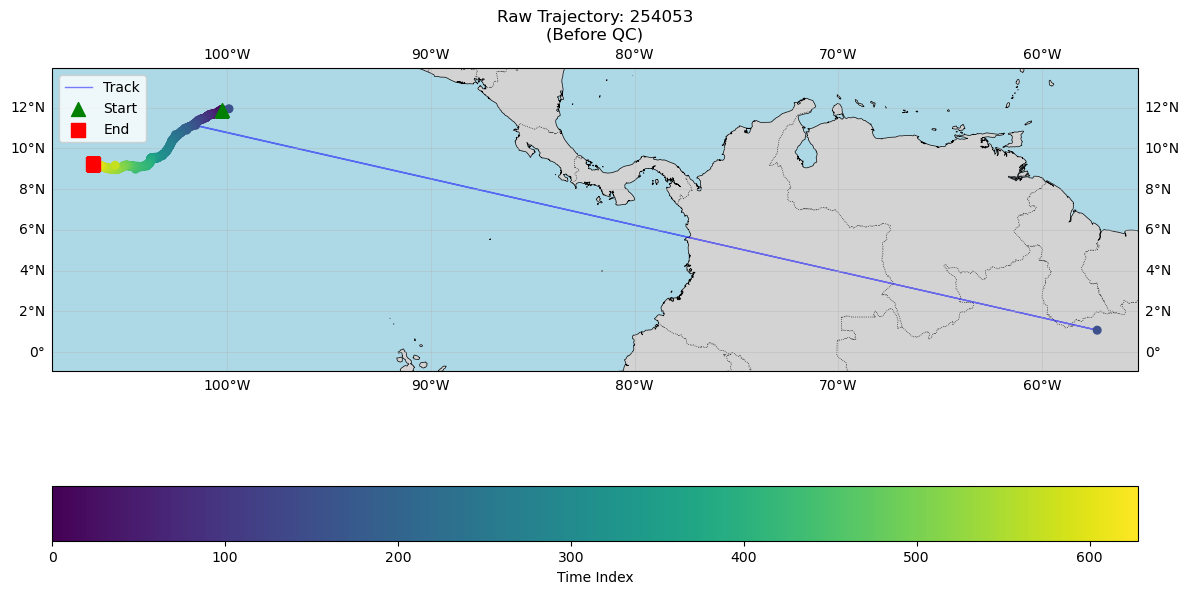


Total points: 629, Valid coordinates: 629


In [7]:
# Visualize the raw track before QC
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Filter valid coordinates for extent calculation
valid_mask = (trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))
valid_data = trajectory_df[valid_mask]

# Set map extent with some padding
lon_min, lon_max = valid_data[lon_col].min() - 2, valid_data[lon_col].max() + 2
lat_min, lat_max = valid_data[lat_col].min() - 2, valid_data[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Plot trajectory
ax.plot(valid_data[lon_col], valid_data[lat_col],
        'b-', linewidth=1, alpha=0.5, transform=ccrs.PlateCarree(), label='Track')
map = ax.scatter(valid_data[lon_col], valid_data[lat_col], 
           c=range(len(valid_data)), cmap='viridis', s=30, 
           transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(map, ax=ax, orientation='horizontal', label='Time Index')

# Mark start and end
ax.scatter(valid_data[lon_col].iloc[0], valid_data[lat_col].iloc[0],
           c='green', s=100, marker='^', transform=ccrs.PlateCarree(), 
           zorder=10, label='Start')
ax.scatter(valid_data[lon_col].iloc[-1], valid_data[lat_col].iloc[-1],
           c='red', s=100, marker='s', transform=ccrs.PlateCarree(), 
           zorder=10, label='End')

# Get deployment ID if available
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Unknown'

ax.legend(loc='upper left')
ax.set_title(f"Raw Trajectory: {deploy_id}\n(Before QC)")
plt.tight_layout()
plt.show()

print(f"\nTotal points: {len(trajectory_df)}, Valid coordinates: {len(valid_data)}")

### 2. Configure QC Tests

Now we'll configure the QC tests using `ioos_qc`. The ATN DAC applies the   Location Test and Speed Test to trajectory data to ensure positions fall within valid geographic bounds and checks for biologically implausable movement speeds. It also tests for being in the valid time range.

In [8]:
# QC Test Thresholds used by ATN DAC
# These are defined based on biological plausibility for marine animals

QC_THRESHOLDS = {
    'location_test': {
        'bbox': [-180, -90, 180, 90],  # Global ocean bounds [lon_min, lat_min, lon_max, lat_max]
        'description': 'Flags positions outside valid geographic range'
    },
    'speed_test': {
        'suspect_threshold': 8.0,  # m/s - high speed, possibly valid for fast swimmers
        'fail_threshold': 10.0,    # m/s - biologically impossible for most marine animals
        'description': 'Flags unrealistic movement speeds between consecutive positions'
    },
    'valid_range_test': {
        'time': {
            'valid_span': [deploy_start, deploy_end],  # Deployment period
            'description': 'Flags observations outside the deployment time period'
        }
    }
}

### 3. Execute QC Tests

Now we'll run the QC tests using `ioos_qc`. We'll apply:

1. **Location Test** (`ioos_qc.qartod`) - Validates that coordinates fall within valid geographic bounds
2. **Speed Test** (`ioos_qc.argo`) - Calculates velocity between consecutive points and flags unrealistic speeds
3. **Valid Range Test** (`ioos_qc.axds`) - Validates that data times fall within the deployment time range

In [9]:
# Run Location Test
from ioos_qc.qartod import location_test

location_flags = location_test(
    lon=trajectory_df[lon_col].values,
    lat=trajectory_df[lat_col].values,
    bbox=QC_THRESHOLDS['location_test']['bbox']
)

trajectory_df['location_test'] = location_flags

In [10]:
print(f"\nLocation test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(location_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

# Show any failed locations
failed_locs = trajectory_df[trajectory_df['location_test'] == 4]
if len(failed_locs) > 0:
    print(f"\nPoints that failed location test: {len(failed_locs)}")
    print(failed_locs[[date_col, lat_col, lon_col, 'location_test']].head())
else:
    print("\n✓ All positions passed the location test")


Location test flag distribution:
  PASS (1): 629

✓ All positions passed the location test


In [11]:
# Run speed test - calculates velocity between consecutive points
from ioos_qc.argo import speed_test

dist = great_circle_distance(trajectory_df[lat_col].values, trajectory_df[lon_col].values)
time_diff = np.diff(trajectory_df['timestamp'].values)
calculated_speed = np.zeros(len(trajectory_df))
calculated_speed[1:] = np.abs(dist[1:] / time_diff)

# Calculate speeds for plotting (this is done internally in ioos_qc)
trajectory_df['calculated_speed'] = calculated_speed

# Run ioos_qc speed test
speed_flags = speed_test(
    lon=trajectory_df[lon_col].values,
    lat=trajectory_df[lat_col].values,
    tinp=trajectory_df['timestamp'].values,
    suspect_threshold=8.0,
    fail_threshold=10.0
)

trajectory_df['speed_test'] = speed_flags

In [12]:
print(f"\nSpeed statistics (m/s):")
print(f"  Min: {trajectory_df['calculated_speed'].min():.4f}")
print(f"  Max: {trajectory_df['calculated_speed'].max():.4f}")
print(f"  Mean: {trajectory_df['calculated_speed'].mean():.4f}")
print(f"  Median: {trajectory_df['calculated_speed'].median():.4f}")

# Show flag distribution
print(f"\nSpeed test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(speed_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")


Speed statistics (m/s):
  Min: 0.0000
  Max: 56499.0716
  Mean: 99.9178
  Median: 0.7894

Speed test flag distribution:
  PASS (1): 577
  NOT_EVAL (2): 1
  SUSPECT (3): 6
  FAIL (4): 45


In [13]:
# Apply valid_range_test to time

from ioos_qc.axds import valid_range_test
    
time_flags = valid_range_test(
    inp=trajectory_df[date_col].values,
    valid_span=[
        deploy_start.isoformat(),
        deploy_end.isoformat()
    ]
)

trajectory_df['time_axds_valid_range_test'] = time_flags

In [14]:

print("\nTime Valid Range Test Results")
print("="*50)
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(time_flags).value_counts().sort_index().items():
    pct = 100 * count / len(time_flags)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")


Time Valid Range Test Results
  PASS (1):   628 (99.8%)
  FAIL (4):     1 (0.2%)


### 4. Interpret QC Flags

The QC tests produce standardized flag values (1=Pass, 2=Not Evaluated, 3=Suspect, 4=Fail, 9=Missing). Let's create a summary of results.

In [15]:
# Create an aggregate QC flag
# The aggregate takes the worst (highest) flag from all tests

trajectory_df['qc_aggregate'] = np.maximum(trajectory_df['location_test'].copy(), 
                                           trajectory_df['speed_test'].copy(), 
                                           trajectory_df['time_axds_valid_range_test'].copy())

# Summary statistics
print("="*60)
print("QC SUMMARY - TRAJECTORY")
print("="*60)
print(f"\nTotal trajectory points: {len(trajectory_df)}")
print(f"\n{'Test':<30} {'Pass':<10} {'Suspect':<10} {'Fail':<10}")
print("-"*60)

for test_name in ['location_test', 'speed_test', 'time_axds_valid_range_test', 'qc_aggregate']:
    flags = trajectory_df[test_name]
    n_pass = (flags == 1).sum()
    n_suspect = (flags == 3).sum()
    n_fail = (flags == 4).sum()
    print(f"{test_name:<30} {n_pass:<10} {n_suspect:<10} {n_fail:<10}")

print("\n" + "="*60)

good_data = (trajectory_df['qc_aggregate'] == 1).sum()
suspect_data = (trajectory_df['qc_aggregate'] == 3).sum()
fail_data = (trajectory_df['qc_aggregate'] == 4).sum()

print(f"\nData Quality Summary:")
print(f"  Good data (flag=1):     {good_data:4d} ({100*good_data/len(trajectory_df):.1f}%)")
print(f"  Suspect data (flag=3):  {suspect_data:4d} ({100*suspect_data/len(trajectory_df):.1f}%)")
print(f"  Failed data (flag=4):   {fail_data:4d} ({100*fail_data/len(trajectory_df):.1f}%)")

QC SUMMARY - TRAJECTORY

Total trajectory points: 629

Test                           Pass       Suspect    Fail      
------------------------------------------------------------
location_test                  629        0          0         
speed_test                     577        6          45        
time_axds_valid_range_test     628        0          1         
qc_aggregate                   577        6          45        


Data Quality Summary:
  Good data (flag=1):      577 (91.7%)
  Suspect data (flag=3):     6 (1.0%)
  Failed data (flag=4):     45 (7.2%)


### 5. Visualize QC Results

Let's create visualizations that show the QC results on our trajectory map and highlight flagged data points.

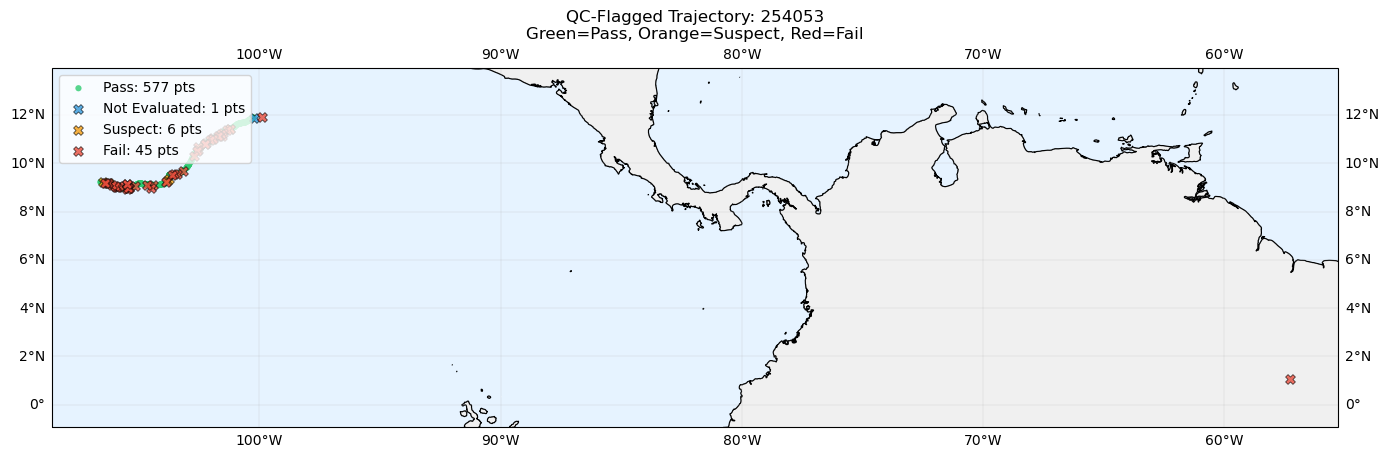

In [16]:
# Create a map showing QC-flagged trajectory
fig, ax = plt.subplots(1, 1, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Use only valid coordinates for extent calculation
valid_coords = trajectory_df[(trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))]
lon_min = valid_coords[lon_col].min() - 2
lon_max = valid_coords[lon_col].max() + 2
lat_min = valid_coords[lat_col].min() - 2
lat_max = valid_coords[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Define colors for each flag value
flag_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
flag_labels = {1: 'Pass', 2: 'Not Evaluated', 3: 'Suspect', 4: 'Fail', 9: 'Missing'}

# Plot trajectory line for good points only
good_mask = trajectory_df['qc_aggregate'] == 1
ax.plot(trajectory_df.loc[good_mask, lon_col], trajectory_df.loc[good_mask, lat_col],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

# Plot points colored by QC flag
for flag_val in sorted(trajectory_df['qc_aggregate'].unique()):
    mask = trajectory_df['qc_aggregate'] == flag_val
    subset = trajectory_df[mask]
    valid_subset = subset[(subset[lat_col].between(-90, 90)) & (subset[lon_col].between(-180, 180))]
    
    if len(valid_subset) > 0:
        ax.scatter(valid_subset[lon_col], valid_subset[lat_col],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, f'Unknown')}: {len(subset)} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5,
                   alpha=0.8)

# Get deployment ID
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Deployment'

ax.legend(loc='upper left', fontsize=10)
ax.set_title(f"QC-Flagged Trajectory: {deploy_id}\nGreen=Pass, Orange=Suspect, Red=Fail", fontsize=12)
plt.tight_layout()
plt.show()

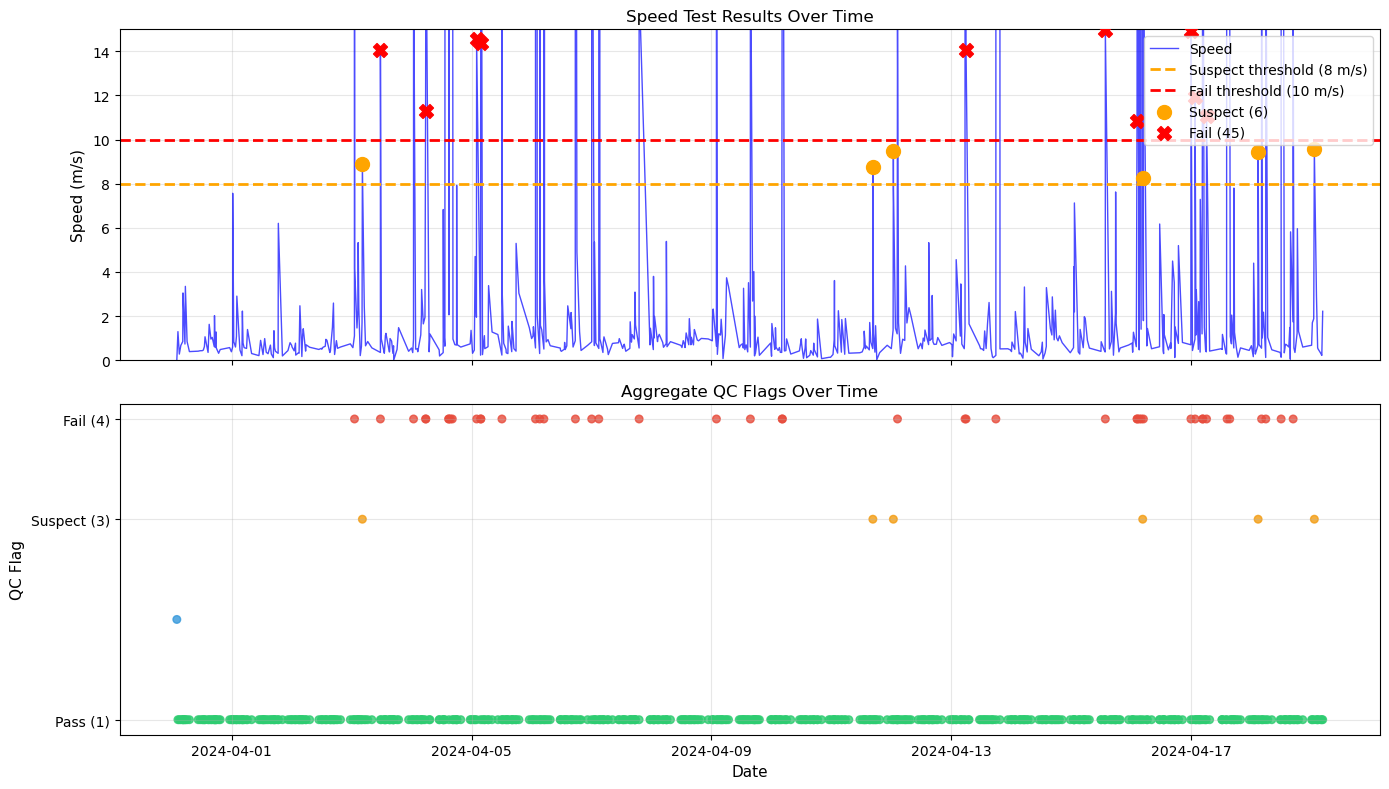

In [17]:
# Create speed time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Speed over time with thresholds
ax1 = axes[0]
ax1.plot(trajectory_df[date_col], trajectory_df['calculated_speed'], 'b-', alpha=0.7, linewidth=1, label='Speed')
ax1.axhline(y=8.0, color='orange', linestyle='--', linewidth=2, label='Suspect threshold (8 m/s)')
ax1.axhline(y=10.0, color='red', linestyle='--', linewidth=2, label='Fail threshold (10 m/s)')

# Highlight flagged points
suspect_mask = trajectory_df['speed_test'] == 3
fail_mask = trajectory_df['speed_test'] == 4
if suspect_mask.any():
    ax1.scatter(trajectory_df.loc[suspect_mask, date_col], trajectory_df.loc[suspect_mask, 'calculated_speed'],
                c='orange', s=100, marker='o', zorder=5, label=f'Suspect ({suspect_mask.sum()})')
if fail_mask.any():
    ax1.scatter(trajectory_df.loc[fail_mask, date_col], trajectory_df.loc[fail_mask, 'calculated_speed'],
                c='red', s=100, marker='X', zorder=5, label=f'Fail ({fail_mask.sum()})')

ax1.set_ylabel('Speed (m/s)', fontsize=11)
ax1.set_title('Speed Test Results Over Time', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Set reasonable y-limit
max_speed = trajectory_df['calculated_speed'].quantile(0.99) if len(trajectory_df) > 10 else trajectory_df['calculated_speed'].max()
ax1.set_ylim(0, min(max_speed * 1.5, 15))

# Plot 2: QC flag values over time  
ax2 = axes[1]
flag_colors_map = {1: '#2ecc71', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
colors = [flag_colors_map.get(f, '#3498db') for f in trajectory_df['qc_aggregate']]
ax2.scatter(trajectory_df[date_col], trajectory_df['qc_aggregate'], c=colors, s=30, alpha=0.8)
ax2.set_ylabel('QC Flag', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_yticks([1, 3, 4])
ax2.set_yticklabels(['Pass (1)', 'Suspect (3)', 'Fail (4)'])
ax2.set_title('Aggregate QC Flags Over Time', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## QC Profile Data

Many Wildlife Computers tags also collect **time-series data** including temperature and depth measurements. For this example, we'll use the SST (Sea Surface Temperature) file which contains temperature measurements.

### 0. Prepare Data

In [18]:
sst_file = "254053O2024/254053-SST.csv"
with zf.open(sst_file) as f:
    profile_df = pd.read_csv(f)

print(f"  Loaded {len(profile_df)} records")
print(f"\nColumns: {list(profile_df.columns)}")
display(profile_df.head())


  Loaded 1019 records

Columns: ['DeployID', 'Ptt', 'DepthSensor', 'Instr', 'Date', 'LocationQuality', 'Latitude', 'Longitude', 'Depth', 'Temperature', 'Source']


,DeployID,Ptt,DepthSensor,Instr,Date,LocationQuality,Latitude,Longitude,Depth,Temperature,Source
0,254053,254053,0.5,MiniPAT,20:00:00 16-Jan-2024,NaN,NaN,NaN,0.4,29.3,TimeSeries
1,254053,254053,0.5,MiniPAT,00:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
2,254053,254053,0.5,MiniPAT,01:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
3,254053,254053,0.5,MiniPAT,02:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
4,254053,254053,0.5,MiniPAT,04:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.0,TimeSeries


In [19]:
temp_col = "Temperature"
depth_col = "Depth"
time_col = "Date"

# Prepare profile dataframe for QC
profile_df[time_col] = pd.to_datetime(profile_df[time_col])
profile_df = profile_df.sort_values(time_col).reset_index(drop=True)

# Define deployment period from the data itself
# In production, these come from the PI-specified deployment dates
deploy_start, deploy_end = profile_df[time_col].min(), profile_df[time_col].max()

In [20]:
print(f"Deployment period: {deploy_start} to {deploy_end}")

print(f"\nTemperature statistics:")
print(f"  Min: {profile_df[temp_col].min():.2f} °C")
print(f"  Max: {profile_df[temp_col].max():.2f} °C")
print(f"  Mean: {profile_df[temp_col].mean():.2f} °C")

Deployment period: 2024-01-16 20:00:00 to 2024-04-19 00:00:00

Temperature statistics:
  Min: 17.40 °C
  Max: 32.60 °C
  Mean: 28.35 °C


### 1. Explore the Profile Data

In [21]:
def plot_profile_data(profile_df, temp_col, time_col):
    # Visualize temperature time series with QC flags
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

    # Plot 1: Temperature time series with QC thresholds
    ax.plot(profile_df[time_col], profile_df[temp_col], 
                'k-', alpha=0.7, linewidth=2, label='Temperature')

    ax.set_ylabel('Temperature (°C)', fontsize=11)
    ax.set_title('Temperature Time Series with Gross Range Test', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # plt.show()
    
    return ax

<Axes: title={'center': 'Temperature Time Series with Gross Range Test'}, ylabel='Temperature (°C)'>

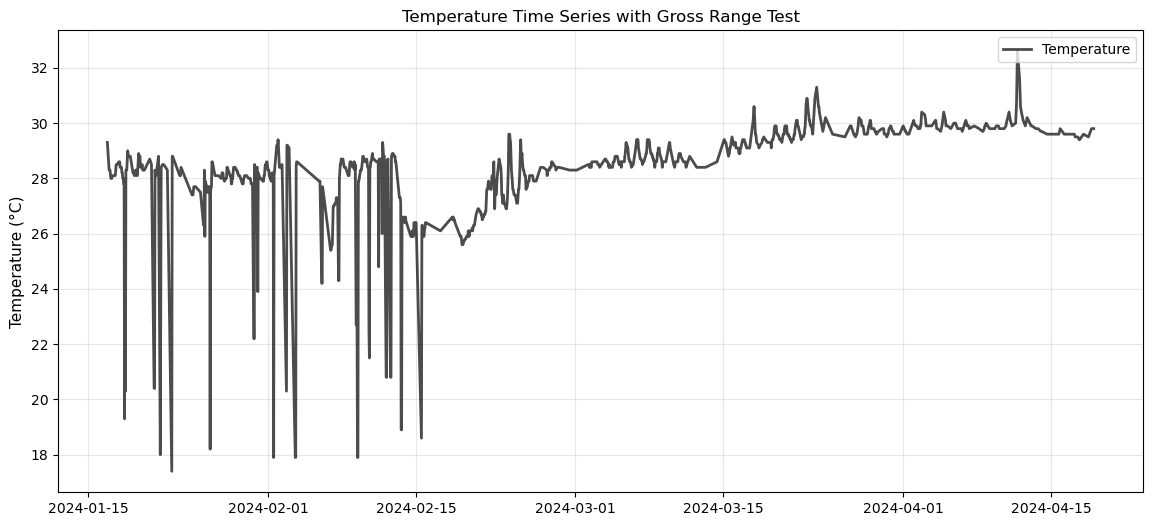

In [22]:
plot_profile_data(profile_df, temp_col, time_col)

### 2. Configure QC Tests

The ATN DAC applies the Gross Range Test and Valid Range Test to profile/time-series data.

The **gross_range_test** (`ioos_qc.qartod`) checks if values fall within physically plausible bounds. For temperature, the ATN DAC uses thresholds from the Argo QC Manual:
- **Fail bounds**: [-2.5, 40] °C (values outside this range are flagged as FAIL)

The **valid_range_test** (`ioos_qc.axds`) checks that observations fall within the deployment time period.

In [23]:
# QC Test Thresholds used by ATN DAC for profile/time-series data
# These are defined based on physical oceanographic bounds

QC_THRESHOLDS = {
    'gross_range_test': {
        'temperature': {
            'fail_span': [-2.5, 40],  # °C - physical bounds for seawater temperature
            'description': 'Flags temperature values outside physically plausible range'
        },
        'salinity': {
            'fail_span': [0, 41],  # PSU - physical bounds for seawater salinity
            'description': 'Flags salinity values outside physically plausible range'
        }
    },
    'valid_range_test': {
        'time': {
            'valid_span': [deploy_start, deploy_end],  # Deployment period
            'description': 'Flags observations outside the deployment time period'
        }
    }
}

### 3. Execute QC Tests

1. The **Gross Range Test** checks for data being within physical limits.
2. The **Valid Range Test** checks that observations fall within the deployment period. This catches data with timestamp errors or data logged before/after the tag was deployed.

In [24]:
# Apply gross_range_test to temperature data

from ioos_qc.qartod import gross_range_test

temp_flags = gross_range_test(
    inp=profile_df[temp_col].values,
    fail_span=QC_THRESHOLDS['gross_range_test']['temperature']['fail_span']
)

profile_df['temperature_qartod_gross_range_test'] = temp_flags

In [25]:
print("Temperature Gross Range Test Results")
print("="*50)
print(f"Fail bounds: [{QC_THRESHOLDS['gross_range_test']['temperature']['fail_span'][0]}, {QC_THRESHOLDS['gross_range_test']['temperature']['fail_span'][1]}] °C")
print(f"\nFlag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(temp_flags).value_counts().sort_index().items():
    pct = 100 * count / len(temp_flags)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")

# Show any failed values
failed_temp = profile_df[profile_df['temperature_qartod_gross_range_test'] == 4]
if len(failed_temp) > 0:
    print(f"\n⚠ {len(failed_temp)} temperature values failed gross_range_test:")
    print(failed_temp[[time_col, temp_col, 'temperature_qartod_gross_range_test']].head(10))
else:
    print(f"\n✓ All temperature values passed the gross_range_test")

Temperature Gross Range Test Results
Fail bounds: [-2.5, 40] °C

Flag distribution:
  PASS (1):  1019 (100.0%)

✓ All temperature values passed the gross_range_test


In [26]:
# Apply valid_range_test to time

from ioos_qc.axds import valid_range_test
    
time_flags = valid_range_test(
    inp=profile_df[time_col].values,
    valid_span=QC_THRESHOLDS['valid_range_test']['time']['valid_span']
)

profile_df['time_axds_valid_range_test'] = time_flags

In [27]:

print("\nTime Valid Range Test Results")
print("="*50)
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(time_flags).value_counts().sort_index().items():
    pct = 100 * count / len(time_flags)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")


Time Valid Range Test Results
  PASS (1):  1018 (99.9%)
  FAIL (4):     1 (0.1%)


### 4. Interpret QC Flags

The QC tests produce standardized flag values. Let's create a summary of results.

In [28]:
# Create an aggregate QC flag
# The aggregate takes the worst (highest) flag from all tests

profile_df['qc_aggregate'] = np.maximum(profile_df['temperature_qartod_gross_range_test'].copy(), 
                                        profile_df['time_axds_valid_range_test'].copy())

# Summary statistics
print("="*60)
print("QC SUMMARY - PROFILE")
print("="*60)
print(f"\nTotal profile points: {len(profile_df)}")
print(f"\n{'Test':<40} {'Pass':<10} {'Suspect':<10} {'Fail':<10}")
print("-"*70)

for test_name in ['temperature_qartod_gross_range_test', 'time_axds_valid_range_test', 'qc_aggregate']:
    flags = profile_df[test_name]
    n_pass = (flags == 1).sum()
    n_suspect = (flags == 3).sum()
    n_fail = (flags == 4).sum()
    print(f"{test_name:<40} {n_pass:<10} {n_suspect:<10} {n_fail:<10}")

print("\n" + "="*60)

good_data = (profile_df['qc_aggregate'] == 1).sum()
suspect_data = (profile_df['qc_aggregate'] == 3).sum()
fail_data = (profile_df['qc_aggregate'] == 4).sum()

print(f"\nData Quality Summary:")
print(f"  Good data (flag=1):     {good_data:4d} ({100*good_data/len(profile_df):.1f}%)")
print(f"  Suspect data (flag=3):  {suspect_data:4d} ({100*suspect_data/len(profile_df):.1f}%)")
print(f"  Failed data (flag=4):   {fail_data:4d} ({100*fail_data/len(profile_df):.1f}%)")

QC SUMMARY - PROFILE

Total profile points: 1019

Test                                     Pass       Suspect    Fail      
----------------------------------------------------------------------
temperature_qartod_gross_range_test      1019       0          0         
time_axds_valid_range_test               1018       0          1         
qc_aggregate                             1018       0          1         


Data Quality Summary:
  Good data (flag=1):     1018 (99.9%)
  Suspect data (flag=3):     0 (0.0%)
  Failed data (flag=4):      1 (0.1%)


### 5. Visualize QC Results

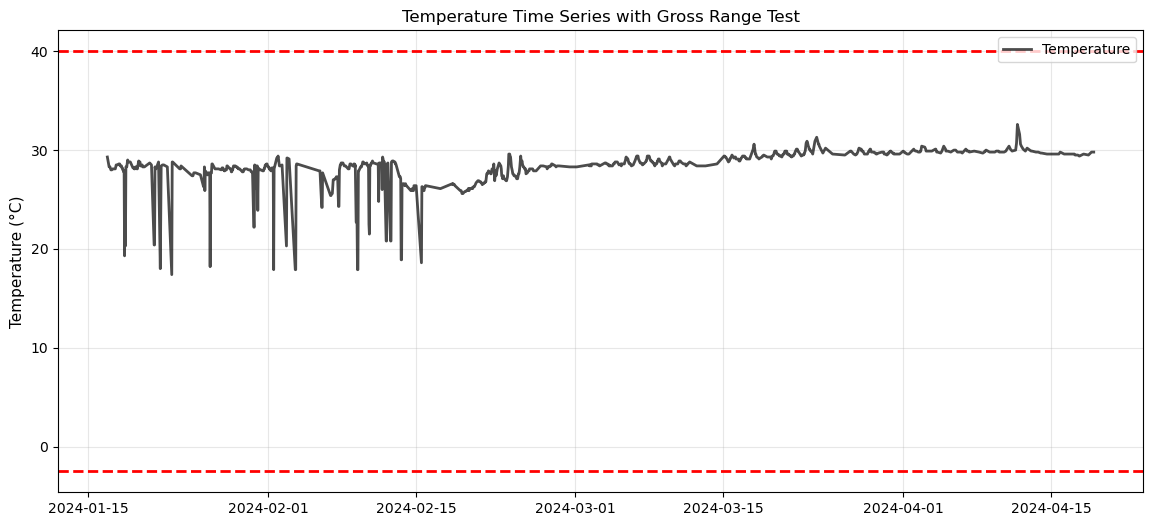

In [29]:
ax = plot_profile_data(profile_df, temp_col, time_col)

# Show QC thresholds
ax.axhline(y=-2.5, color='red', linestyle='--', linewidth=2, 
            label='Fail bounds [-2.5, 40]°C')
ax.axhline(y=40, color='red', linestyle='--', linewidth=2)

# Highlight any failed points
fail_mask = profile_df['temperature_qartod_gross_range_test'] == 4
if fail_mask.any():
    ax.scatter(profile_df.loc[fail_mask, time_col], 
                profile_df.loc[fail_mask, temp_col],
                c='red', s=50, marker='X', zorder=5, 
                label=f'Failed ({fail_mask.sum()})')

## Batch QC

The ATN DAC production pipeline runs QC tests using `ioos_qc`'s `PandasStream` and `PandasStore` classes. This approach:
1. Applies all configured tests in a single pass
2. Automatically computes aggregate (rollup) flags
3. Produces standardized output column names

Here's how batch QC works for both trajectory and profile data:

In [74]:
# Batch QC approach for trajectory data using PandasStream

def apply_qc(df, qc_config_yaml, time=None, lon=None, lat=None, z=None):
    """Apply batch QC to a DataFrame using ioos_qc PandasStream.
    
    time, lon, lat, z: column names in df for the respective axes.
    PandasStream uses these to automatically pass tinp/lon/lat to each test.
    """
    config = Config(qc_config_yaml)
    stream = PandasStream(df, time=time, lon=lon, lat=lat, z=z)
    results = stream.run(config)
    
    store_axes = {}
    if time: store_axes['t'] = time
    if lon:  store_axes['x'] = lon
    if lat:  store_axes['y'] = lat
    if z:    store_axes['z'] = z
    
    store = PandasStore(results, axes=store_axes)
    store.compute_aggregate()
    results_df = store.save(write_data=False, write_axes=False)
    
    return pd.concat([df, results_df], axis=1)

# Build QC configuration YAML for trajectory
traj_start = trajectory_df[date_col].min()
traj_end = trajectory_df[date_col].max()

trajectory_qc_yaml = f"""
{lon_col}:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
{lat_col}:
    argo:
        speed_test:
            suspect_threshold: 8.0
            fail_threshold: 10.0
{date_col}:
    axds:
        valid_range_test:
            valid_span:
                - {traj_start}
                - {traj_end}
"""

print("Trajectory QC Configuration (YAML format):")
print(trajectory_qc_yaml)

# Run QC 
trajectory_qc_results = apply_qc(
    trajectory_df,
    trajectory_qc_yaml,
    time=date_col, lon=lon_col, lat=lat_col
)

print("\n" + "="*50)
print("Trajectory QC Results")
print("="*50)

print(f"\nAggregate QC (qartod_rollup) distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in trajectory_qc_results['qartod_rollup'].value_counts().sort_index().items():
    pct = 100 * count / len(trajectory_qc_results)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")

Trajectory QC Configuration (YAML format):

Longitude:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
Latitude:
    argo:
        speed_test:
            suspect_threshold: 8.0
            fail_threshold: 10.0
Date:
    axds:
        valid_range_test:
            valid_span:
                - 2024-03-31 02:03:56
                - 2024-04-19 04:35:53


Trajectory QC Results

Aggregate QC (qartod_rollup) distribution:
  PASS (1):   577 (91.7%)
  SUSPECT (3):     6 (1.0%)
  FAIL (4):    46 (7.3%)


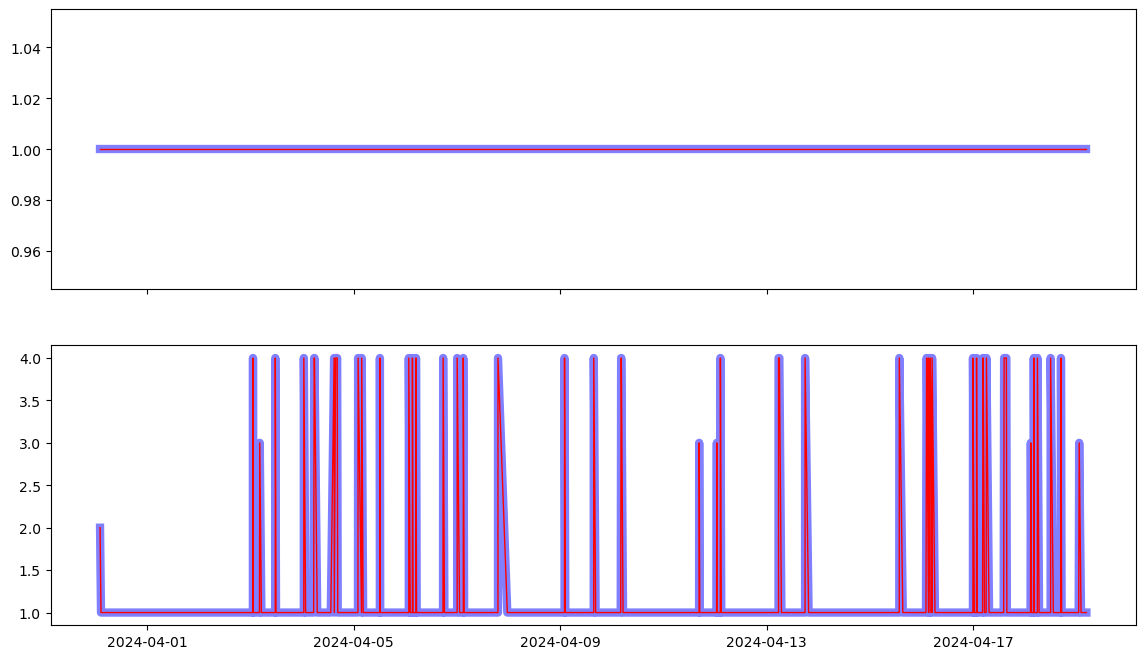

In [75]:
# make sure the QC results match for rollup
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(trajectory_df[date_col], trajectory_df['location_test'], 'b-', alpha=0.5, linewidth=6, label='Speed')
ax[0].plot(trajectory_qc_results[date_col], trajectory_qc_results['location_test'], 'r-', alpha=1, linewidth=1, label='QC Speed')

ax[1].plot(trajectory_df[date_col], trajectory_df['speed_test'], 'b-', alpha=0.5, linewidth=6, label='Speed')
ax[1].plot(trajectory_qc_results[date_col], trajectory_qc_results['speed_test'], 'r-', alpha=1, linewidth=1, label='QC Speed')

In [78]:
# Batch QC for profile data

prof_start = profile_df[time_col].min()
prof_end = profile_df[time_col].max()

profile_qc_yaml = f"""
{time_col}:
    axds:
        valid_range_test:
            valid_span:
                - {prof_start}
                - {prof_end}
{temp_col}:
    qartod:
        gross_range_test:
            fail_span: [-2.5, 40]
"""

print("Profile QC Configuration (YAML format):")
print(profile_qc_yaml)

# Run QC
profile_qc_results = apply_qc(
    profile_df,
    profile_qc_yaml,
    time=time_col,
    lon=lon_col if lon_col in profile_df.columns else None,
    lat=lat_col if lat_col in profile_df.columns else None,
    z=depth_col if depth_col in profile_df.columns else None,
)

print("\n" + "="*50)
print("Profile QC Results")
print("="*50)

print(f"\nAggregate QC (qartod_rollup) distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in profile_qc_results['qartod_rollup'].value_counts().sort_index().items():
    pct = 100 * count / len(profile_qc_results)
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")

Profile QC Configuration (YAML format):

Date:
    axds:
        valid_range_test:
            valid_span:
                - 2024-01-16 20:00:00
                - 2024-04-19 00:00:00
Temperature:
    qartod:
        gross_range_test:
            fail_span: [-2.5, 40]


Profile QC Results

Aggregate QC (qartod_rollup) distribution:
  PASS (1):  1018 (99.9%)
  FAIL (4):     1 (0.1%)


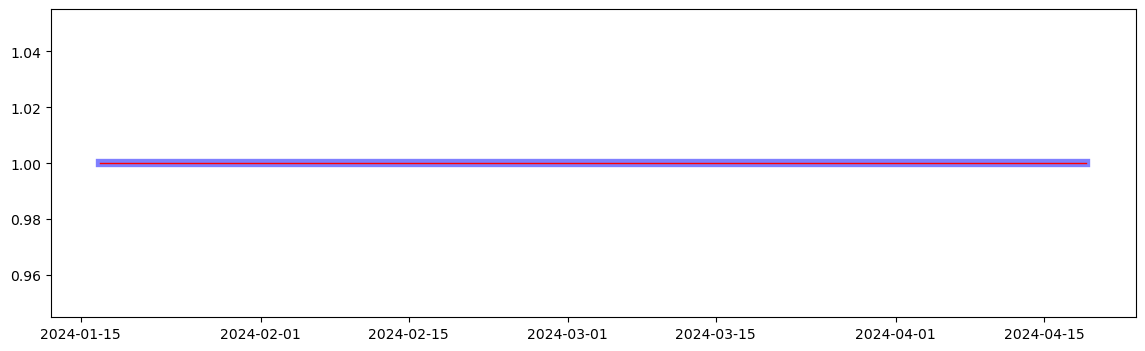

In [79]:
# make sure the QC results match for rollup
fig, ax = plt.subplots(1, 1, figsize=(14, 4), sharex=True)

ax.plot(profile_df[date_col], profile_df['temperature_qartod_gross_range_test'], 'b-', alpha=0.5, linewidth=6, label='Temperature')
ax.plot(profile_qc_results[date_col], profile_qc_results['temperature_qartod_gross_range_test'], 'r-', alpha=1, linewidth=1, label='QC Temperature')


## References

- [ATN Data Portal](https://portal.atn.ioos.us/)
- [IOOS QARTOD Manual](https://ioos.noaa.gov/project/qartod/)
- [ioos_qc Documentation](https://ioos.github.io/ioos_qc/)
- [Argo Quality Control Manual](https://archimer.ifremer.fr/doc/00228/33951/)
- [Wildlife Computers Data Portal](https://my.wildlifecomputers.com/)
- [ATN Satellite Telemetry Specification](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html)